# Quickstart

This guide demonstrates a minimal working example of the `qiskit-paulice` package. We use [spacetime Pauli checks](https://arxiv.org/abs/2504.15725) to detect errors during execution of a Clifford circuit, then postselect only samples for which no error was detected. For a more explanatory end-to-end workflow that quantifies the fidelity improvement, see the [in-depth tutorial](https://github.com/Qiskit/qiskit-paulice/blob/main/docs/guides/low_overhead_error_detection_using_spacetime_codes.ipynb).

**Workflow steps**
1. Prepare the inputs: a Clifford payload circuit, the target/ancilla qubits to host checks, and a noise model.
2. Find good spacetime Pauli checks and add them to the circuit.
3. Sample the checked circuit.
4. Postselect only the samples for which no error was detected.

## 1. Prepare the inputs

`add_pauli_checks` takes a Clifford **circuit** with at least one terminal measurement, the **target qubits** that will be used to implement checks, and a **noise model** used to score candidate checks. Here we build a shallow random Clifford circuit, lay it out on a 1D chain of physical qubits on `ibm_boston`, pair each payload qubit with a neighboring ancilla (so a check needs no SWAP gates), and infer a rough depolarizing noise model from backend benchmark data.

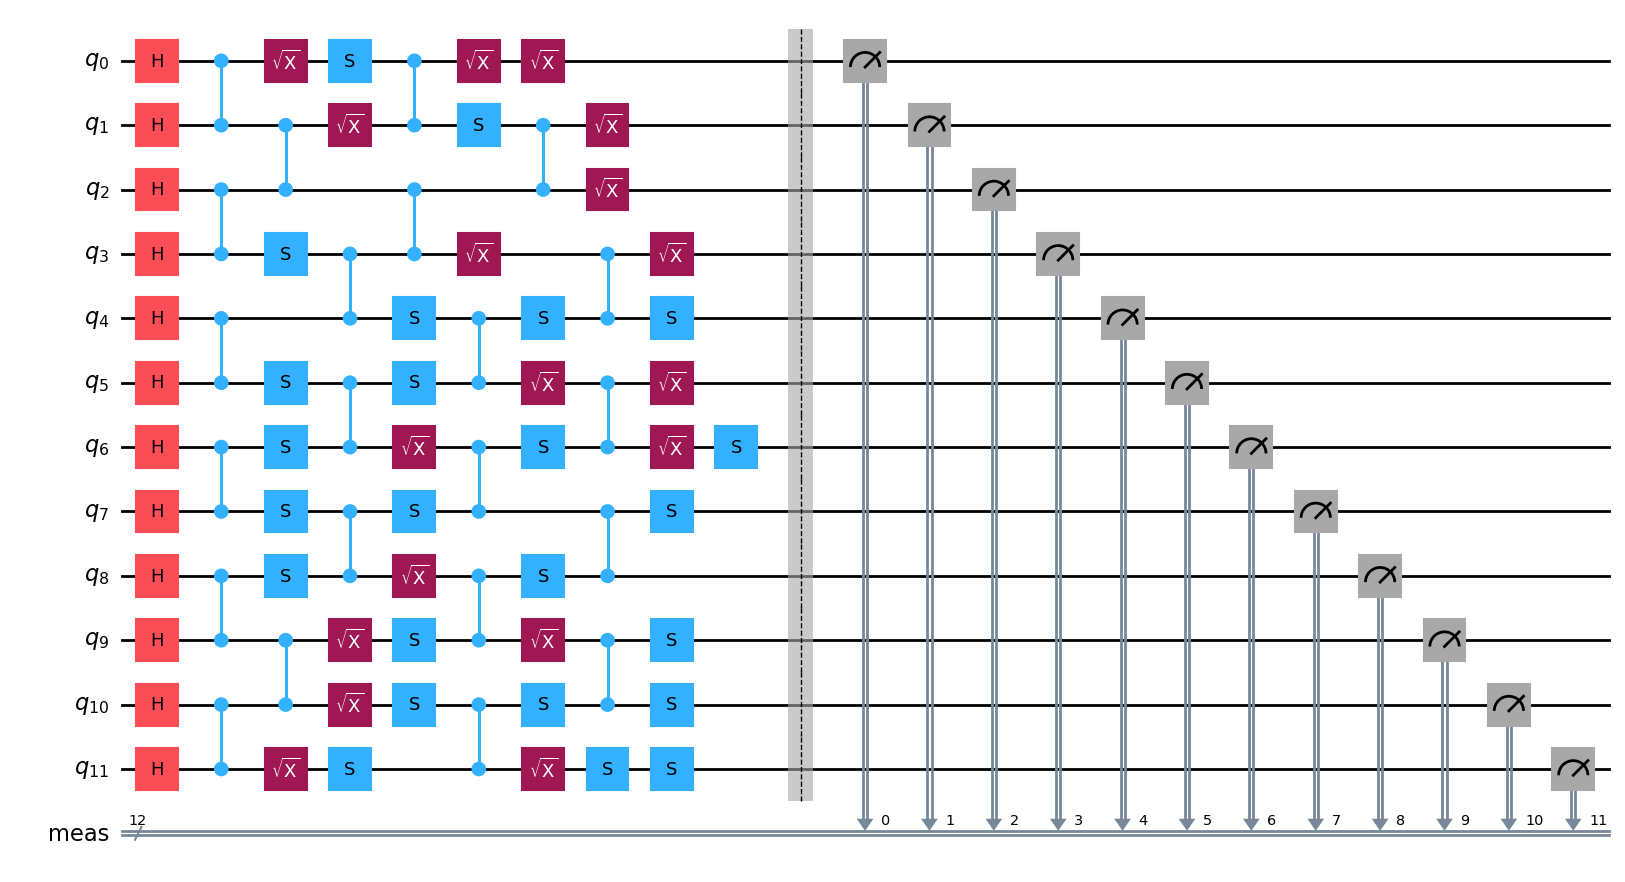

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_paulice.layout import get_check_qubits
from qiskit_paulice.noise_models import NoiseModel

# Backend and a 1D chain of physical qubits to run on
backend = QiskitRuntimeService().backend("ibm_boston")
layout = [68, 69, 78, 89, 90, 91, 98, 111, 112, 113, 119, 133]

# A shallow brickwork random Clifford payload circuit
rng = np.random.default_rng(1764)
circuit = QuantumCircuit(len(layout))
circuit.h(range(circuit.num_qubits))
for d in range(4):
    for i in range(d % 2, circuit.num_qubits - 1, 2):
        circuit.cz(i, i + 1)
    for q in range(circuit.num_qubits):
        if rng.integers(0, 2):
            circuit.sx(q)
        if rng.integers(0, 2):
            circuit.s(q)
circuit.measure_all()

# Pair each payload qubit with a neighboring ancilla to host a check (no SWAPs needed)
target_qubits, ancilla_qubits = get_check_qubits(backend.coupling_map, layout)

# A rough depolarizing noise model from backend benchmark data, used to score checks
noise_model = NoiseModel.from_backend(backend, layout, uniform_gate_noise=True)

circuit.draw("mpl", fold=-1)

## 2. Find and add spacetime Pauli checks

`add_pauli_checks` searches for effective, low-weight checks on each target qubit and adds them to the circuit, returning a sequence of `CheckedCircuit` instances. The `CheckedCircuit` instances contain increasing numbers of checks, from ``0`` checks up to one check per target qubit. Each check improves error detection capability at the cost of a slightly increased circuit depth. For this example we will use the circuit with a check on every target qubit.

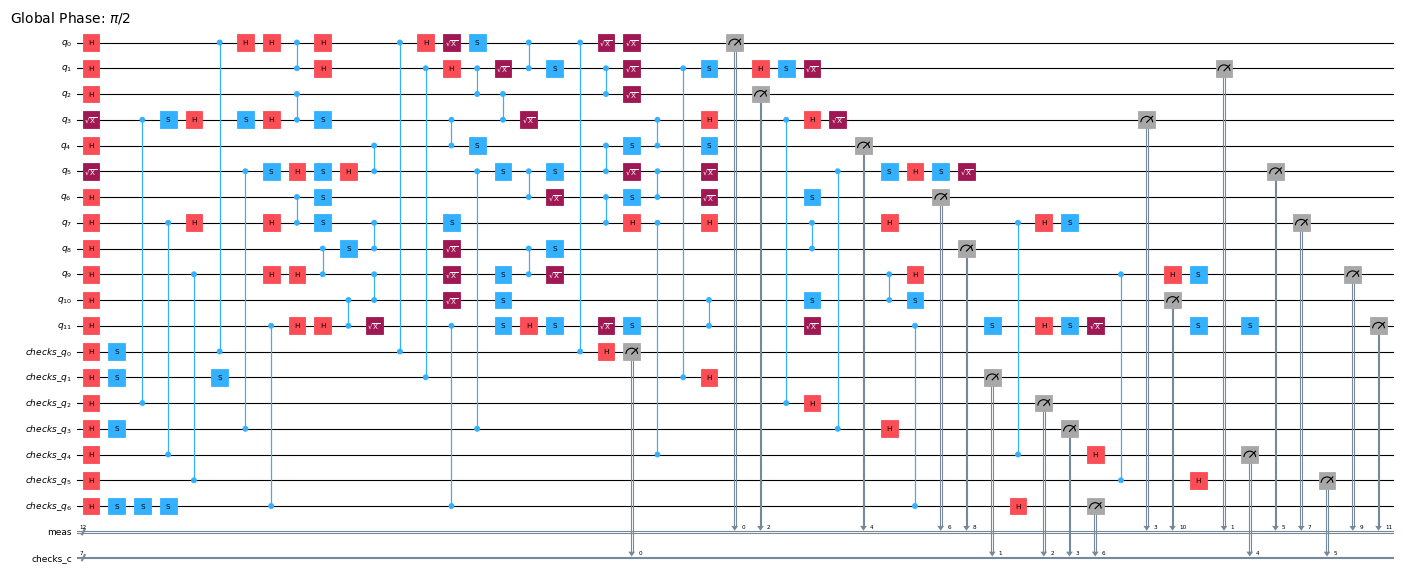

In [2]:
from qiskit_paulice import add_pauli_checks

# The circuit has virtual qubits, so we specify our target qubits with virtual indices
target_qubits_v = [layout.index(q) for q in target_qubits]

# Add spacetime Pauli checks
checked_circuit = add_pauli_checks(circuit, target_qubits_v, noise_model)[-1]
checked_circuit.circuit.draw("mpl", fold=-1, scale=0.4, idle_wires=False)

## 3. Sample the checked circuit

Before we sample, we transpile the checked circuit onto physical qubits (`initial_layout = layout + ancilla_qubits`) and into `ibm_boston`'s native basis gate set. To emulate a noisy QPU, we sample with a noisy Aer stabilizer backend whose error rates match the `noise_model` used to pick checks.

In [3]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel as AerNoiseModel
from qiskit_aer.noise import ReadoutError, depolarizing_error

# Transpile once: lay the checked circuit out on our qubits and into the native basis
isa_circuit = transpile(
    checked_circuit.circuit, backend, initial_layout=layout + ancilla_qubits, optimization_level=0
)

# Build an Aer noise model matching the depolarizing model used to pick checks
aer_noise = AerNoiseModel()
aer_noise.add_all_qubit_quantum_error(depolarizing_error(noise_model.gate_noise, 2), ["cz"])
p = noise_model.readout_noise
aer_noise.add_all_qubit_readout_error(ReadoutError([[1 - p, p], [p, 1 - p]]))
simulator = AerSimulator(method="stabilizer", noise_model=aer_noise)

counts = simulator.run(isa_circuit, shots=1000, seed_simulator=1764).result().get_counts()
print(f"sampled {sum(counts.values())} shots")

sampled 1000 shots


## 4. Postselect samples with no detected error

`get_postselection_method` maps each shot to its syndrome vector; we keep only the shots with an all-zero syndrome &mdash; those in which no check detected an error. Discarding the flagged shots removes detected errors from the surviving distribution, improving its fidelity at the cost of a lower sampling rate. See the [tutorial](https://github.com/Qiskit/qiskit-paulice/blob/main/docs/guides/low_overhead_error_detection_using_spacetime_codes.ipynb) for a quantitative fidelity comparison.

In [4]:
# Keep only the shots in which no check reported an error
ps_fn = checked_circuit.get_postselection_method()
counts_postselected = {bs: n for bs, n in counts.items() if not ps_fn(bs).any()}

kept, total = sum(counts_postselected.values()), sum(counts.values())
print(f"kept {kept} of {total} shots ({kept / total:.0%})")

kept 927 of 1000 shots (93%)
